# experiments.py
Conducts the specified experiments on the simple CNN model to evaluate efficiency and accuracy

# Assignment 3
### CSC 537: Deep Learning

**Author:** Xander Palermo — ajp2s@missouristate.edu <br>
**Professor:** Mukulika Ghosh <br>
**Date:** 3 April 2026

----

## Imports

Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision.models as models
import pickle

from cnn import *  # custom class implementation

Imported helper functions (from prev. assignments)

In [2]:
plot_path = "./results/"

def save_plot (exp_plot, exp_num, exp_name, suffix = "") -> None:
    """
    Saves a plot to designated location
    :param exp_plot: the experiment's plot
    :param exp_num: the experiment's number
    :param exp_name: the experiment's name
    :param suffix: (optional) a title suffix to differentiate plots from the same experiment
    :return: None
    """
    file_type = ".png"
    complete_path = plot_path + f"exp_{exp_num}/{exp_name}" + suffix + file_type
    exp_plot.savefig(complete_path)
    print(f'\t\t saved to {complete_path}')


def gen_plot(df: pd.DataFrame,
             independent_var : str,
             experiment_number: int, experiment_title: str,
             dependent_var: str = "Loss",
             subtitle : str = None
             ) -> sns.FacetGrid:
    """
    generates a grid of plots for the experiment
    :param df: DataFrame containing data to be plotted. Data Frame should have a column containing Iterations, and 2 columns mapping Independent Variable -> Dependent Variable
    :param independent_var: the variable that is being changed for each execution of the gradient descent algorithm
    :param experiment_number: The experiment number
    :param experiment_title: The experiment title
    :param dependent_var: (DEFAULT: LOSS) the value to be tracked over iterations
    :param subtitle: (DEFAULT: none included) a descriptor of what the graph displays
    :return:
    """
    g = sns.relplot(
        data=df,
        kind='line', x='Epoch', y=dependent_var,
        hue=independent_var, legend=True
    )
    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle(f"Experiment {experiment_number}: {experiment_title}")
    if subtitle is not None:
        g.fig.text(0.5, 0.91, subtitle, ha='center', fontsize=10, color='gray')
    return g


Custom Helper Function (derived from save_plot)

In [3]:
def save_table(df : pd.DataFrame, exp_num, exp_name, suffix = "") -> None:
    """
    Saves a dataframe as a table to designated location.

    Saves as Microsoft Excel spreadsheet
    :param df: the experiment's plot
    :param exp_num: the experiment's number
    :param exp_name: the experiment's name
    :param suffix: (optional) a title suffix to differentiate plots from the same experiment
    :return: None
    """
    file_type = ".xlsx"
    complete_path = plot_path + f"exp_{exp_num}/{exp_name}" + suffix + file_type
    df.to_excel(complete_path)
    print(f'\t\t saved to {complete_path}')

## Start Up

Unpickle compiled DataLoader Objects

In [4]:
path = "./dataset/"
with open(path + "training.pkl", 'rb') as f:
    training_data = pickle.load(f)

with open(path + "validation.pkl", 'rb') as f:
    validation_data = pickle.load(f)

with open(path + "testing.pkl", 'rb') as f:
    testing_data = pickle.load(f)

Initialize GPU (if available)

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device == torch.device('cuda'):
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 2060


Configure Seaborn Plot

In [6]:
sns.set_style("whitegrid")
sns.set_palette("bright")

---

## Experiment A
*Depth Comparison*  <br>
Compare convergence behavior and validation behavior on models with varying depth.

In [7]:
experiment_title = "Depth Comparison"
experiment_number = 1
independent_variable = "Depth"

**Independent Variables**

In [8]:
shallow_network = SimpleCNN(2) # Control
deep_network = SimpleCNN(3)

### Experiment

Perform Training and Validation on models and capture statistical data  <br>
Each network is given 100 epoches to train over, to study how overfitting occurs in both models  <br>
Each network is individually timed

In [9]:
total_cycles = 150

In [10]:
%%time
print("Starting Training on shallow network...")
shallow_network, shallow_train_loss, shallow_valid_loss, shallow_valid_accuracy = train(shallow_network, training_data, validation_data, verbose=True, device=device, TOTAL_EPOCHES=total_cycles)
print("Training on shallow network complete!")

torch.cuda.synchronize()

Starting Training on shallow network...
		Epoch 1/150
			training avg_loss=1.6562
			validation avg_loss=1.5031
			accuracy=45.88%
		Epoch 11/150
			training avg_loss=0.8326
			validation avg_loss=0.8789
			accuracy=68.40%
		Epoch 21/150
			training avg_loss=0.6387
			validation avg_loss=0.8048
			accuracy=73.00%
		Epoch 31/150
			training avg_loss=0.5341
			validation avg_loss=0.6388
			accuracy=77.74%
		Epoch 41/150
			training avg_loss=0.4875
			validation avg_loss=0.5843
			accuracy=79.98%
		Epoch 51/150
			training avg_loss=0.4421
			validation avg_loss=0.6121
			accuracy=78.88%
		Epoch 61/150
			training avg_loss=0.4012
			validation avg_loss=0.5806
			accuracy=80.05%
		Epoch 71/150
			training avg_loss=0.3843
			validation avg_loss=0.6109
			accuracy=79.14%
		Epoch 81/150
			training avg_loss=0.3655
			validation avg_loss=0.5861
			accuracy=80.76%
		Epoch 91/150
			training avg_loss=0.3366
			validation avg_loss=0.5882
			accuracy=80.87%
		Epoch 101/150
			training avg_loss=0.33

In [11]:
%%time
print("Starting Testing on deep network...")
deep_network, deep_train_loss, deep_verify_loss, deep_valid_accuracy = train(deep_network, training_data, validation_data, verbose=True, device=device,  TOTAL_EPOCHES=total_cycles )
print("Testing on deep network complete!")

torch.cuda.synchronize()

Starting Testing on deep network...
		Epoch 1/150
			training avg_loss=1.6977
			validation avg_loss=1.5093
			accuracy=44.61%
		Epoch 11/150
			training avg_loss=0.7183
			validation avg_loss=0.7570
			accuracy=73.71%
		Epoch 21/150
			training avg_loss=0.5336
			validation avg_loss=0.6321
			accuracy=78.16%
		Epoch 31/150
			training avg_loss=0.4336
			validation avg_loss=0.6187
			accuracy=78.91%
		Epoch 41/150
			training avg_loss=0.3681
			validation avg_loss=0.5476
			accuracy=81.91%
		Epoch 51/150
			training avg_loss=0.3180
			validation avg_loss=0.5631
			accuracy=81.96%
		Epoch 61/150
			training avg_loss=0.2956
			validation avg_loss=0.5312
			accuracy=82.78%
		Epoch 71/150
			training avg_loss=0.2787
			validation avg_loss=0.5407
			accuracy=82.90%
		Epoch 81/150
			training avg_loss=0.2596
			validation avg_loss=0.5266
			accuracy=83.57%
		Epoch 91/150
			training avg_loss=0.2407
			validation avg_loss=0.5319
			accuracy=83.54%
		Epoch 101/150
			training avg_loss=0.2397
	

Perform final testing on models and capture statistical data

In [12]:
shallow_test_loss, shallow_test_accuracy = [], []
deep_test_loss, deep_test_accuracy = [], []

In [13]:
%%time
print("Starting Testing on shallow network complete!")
evaluate(shallow_network, testing_data, shallow_test_loss, shallow_test_accuracy)
print("Testing on shallow network complete!")

torch.cuda.synchronize()

Starting Testing on shallow network complete!
Testing on shallow network complete!
CPU times: total: 10.3 s
Wall time: 23.5 s


In [14]:
%%time
print("Starting Testing on deep network complete!")
evaluate(deep_network, testing_data, deep_test_loss, deep_test_accuracy)
print("Testing on deep network complete!")

torch.cuda.synchronize()

Starting Testing on deep network complete!
Testing on deep network complete!
CPU times: total: 1min
Wall time: 1min 14s


### Plotting

Construct DataFrame objects to compare each stage of training

In [15]:
training_loss = pd.DataFrame({
    "Shallow"   : shallow_train_loss,
    "Deep"      : deep_train_loss,
})

validation_loss =  pd.DataFrame({
    "Shallow"   : shallow_valid_loss,
    "Deep"      : deep_verify_loss,
})

validation_accuracy =  pd.DataFrame({
    "Shallow"   : shallow_valid_accuracy,
    "Deep"      : deep_valid_accuracy,
})

plot_data_loss = {
    "Training Loss" : training_loss,
    "Validation Loss" : validation_loss
}

results = pd.DataFrame({
    independent_variable: ["Shallow", "Deep"],
    "Test Loss": [shallow_test_loss[0], deep_test_loss[0]],
    "Test Accuracy (%)": [shallow_test_accuracy[0], deep_test_accuracy[0]]
})

Prepare DataFrame and plot results generated by the loss function

In [16]:
plots = dict()

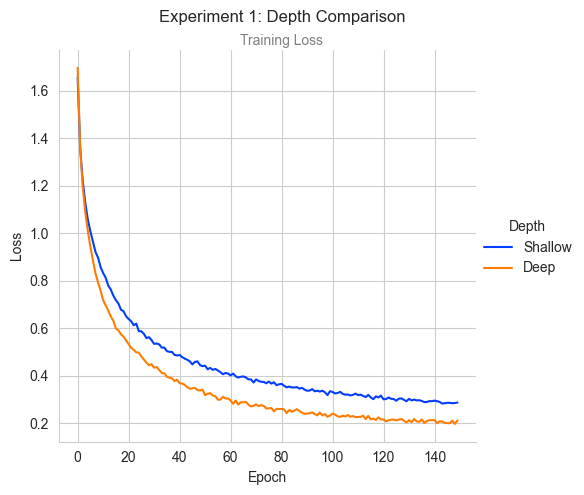

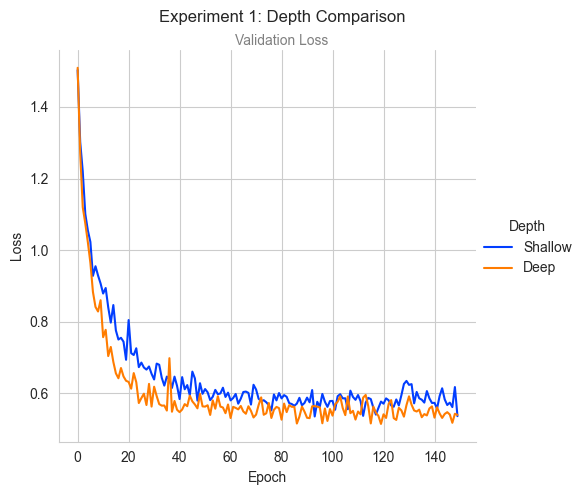

In [17]:
for identifier, df in plot_data_loss.items():
    df["Epoch"] = df.index
    df = pd.melt(df, id_vars=["Epoch"], var_name=independent_variable, value_name="Loss")
    # print(df)
    plots[identifier] = gen_plot(df, independent_variable, experiment_number, experiment_title, subtitle=identifier)
    plt.show()

Prepare DataFrame containing validation accuracy data and plot

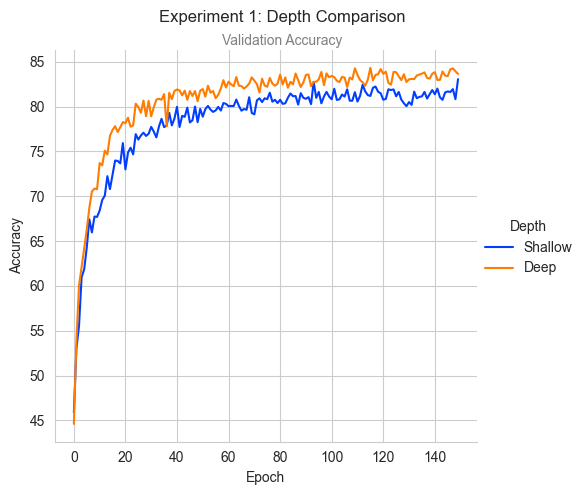

In [18]:
validation_accuracy["Epoch"] = validation_accuracy.index
validation_accuracy = pd.melt(validation_accuracy, id_vars=["Epoch"], var_name=independent_variable, value_name="Accuracy")
# print(df)
plots["Validation Accuracy"] = gen_plot(validation_accuracy, independent_variable, experiment_number, experiment_title, dependent_var="Accuracy", subtitle="Validation Accuracy")
plt.show()

Construct table of final test results

In [19]:
results.set_index(independent_variable, inplace=True)
display(results)

,Test Loss,Test Accuracy (%)
Depth,,
Shallow,0.563614,83.40
Deep,0.549432,84.73


Save all figures to disk

In [20]:
for identifier, g in plots.items():
    save_plot(g, experiment_number, experiment_title, suffix=f" - {identifier}")

save_table(results, experiment_number, experiment_title, suffix=f" - Results")


		 saved to ./results/exp_1/Depth Comparison - Training Loss.png
		 saved to ./results/exp_1/Depth Comparison - Validation Loss.png
		 saved to ./results/exp_1/Depth Comparison - Validation Accuracy.png
		 saved to ./results/exp_1/Depth Comparison - Results.xlsx


---

## Experiment B
*Architecture Comparison* <br>
Comparing Simple CNN-Deep with a ResNet architecture to study how optimizations made in ResNet affect performance

In [21]:
experiment_title = "Architecture Comparison"
experiment_number = 2
independent_variable = "Architecture"

**Independent Variables**

Initialize each model

In [22]:
simple_cnn = SimpleCNN(depth=3)

resnet = models.resnet18(weights=None)
resnet.fc = torch.nn.Linear(resnet.fc.in_features, 10)

Count Trainable parameters in each model

In [23]:
print("Trainable Parameters:")
cnn_params = sum(p.numel() for p in simple_cnn.parameters() if p.requires_grad)
resnet_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)

print(f'\t{"Simple CNN:":13} {cnn_params:,}')
print(f'\t{"ResNet:":13} {resnet_params:,}')

Trainable Parameters:
	Simple CNN:   483,402
	ResNet:       11,181,642


### Experiment

Perform Training and Validation on models and capture statistical data  <br>
*Notes*

- Epsilon is set to prevent overfitting and provide more information about convergence speed

- Each network is individually timed

In [24]:
epsilon = 0.0001

In [25]:
%%time
print("Starting training on Simple CNN...")
simple_cnn, simple_train_loss, simple_valid_loss, simple_valid_accuracy = train(simple_cnn, training_data, validation_data, verbose=True, device=device, THRESH= 0.001)
print("Training on Simple CNN complete!")

torch.cuda.synchronize()

Starting training on Simple CNN...
		Epoch 1/100
			training avg_loss=1.6681
			validation avg_loss=1.4631
			accuracy=46.27%
		Epoch 11/100
			training avg_loss=0.7041
			validation avg_loss=0.7180
			accuracy=74.97%
		Epoch 21/100
			training avg_loss=0.5286
			validation avg_loss=0.6306
			accuracy=78.57%
		Epoch 31/100
			training avg_loss=0.4344
			validation avg_loss=0.5896
			accuracy=80.03%
		Epoch 41/100
			training avg_loss=0.3758
			validation avg_loss=0.5656
			accuracy=80.59%
		Epoch 51/100
			training avg_loss=0.3308
			validation avg_loss=0.5557
			accuracy=81.96%
		Epoch 61/100
			training avg_loss=0.3015
			validation avg_loss=0.5507
			accuracy=82.22%
		Epoch 71/100
			training avg_loss=0.2799
			validation avg_loss=0.5174
			accuracy=83.14%
		Epoch 81/100
			training avg_loss=0.2675
			validation avg_loss=0.5808
			accuracy=81.81%
		Epoch 91/100
			training avg_loss=0.2443
			validation avg_loss=0.5293
			accuracy=83.35%
Training on Simple CNN complete!
CPU times: to

In [26]:
%%time
print("Starting training on ResNet...")
resnet, rn_train_loss, rn_valid_loss, rn_valid_accuracy = train(resnet, training_data, validation_data, verbose=True, device=device, THRESH= 0.001)
print("Training on ResNet complete!")

torch.cuda.synchronize()

Starting training on ResNet...
		Epoch 1/100
			training avg_loss=1.8190
			validation avg_loss=1.6443
			accuracy=41.30%
		Epoch 11/100
			training avg_loss=0.9974
			validation avg_loss=1.0039
			accuracy=64.92%
		Epoch 21/100
			training avg_loss=0.7963
			validation avg_loss=0.8497
			accuracy=70.53%
		Epoch 31/100
			training avg_loss=0.6810
			validation avg_loss=0.7924
			accuracy=72.99%
		Epoch 41/100
			training avg_loss=0.5979
			validation avg_loss=0.7660
			accuracy=74.49%
		Epoch 51/100
			training avg_loss=0.5554
			validation avg_loss=0.7470
			accuracy=74.96%
Training on ResNet complete!
CPU times: total: 13min 23s
Wall time: 41min 10s


Perform final testing on models and capture statistical data

In [27]:
simple_test_loss, simple_test_accuracy = [], []
rn_test_loss, rn_test_accuracy = [], []

In [28]:
%%time
print("Starting testing on Simple CNN...")
evaluate(simple_cnn, testing_data, simple_test_loss, simple_test_accuracy)
print("Testing on Simple CNN complete!")

torch.cuda.synchronize()

Starting testing on Simple CNN...
Testing on Simple CNN complete!
CPU times: total: 57 s
Wall time: 1min 10s


In [29]:
%%time
print("Starting testing on ResNet...")
evaluate(resnet, testing_data, rn_test_loss, rn_test_accuracy)
print("Testing on ResNet complete!")

torch.cuda.synchronize()

Starting testing on ResNet...
Testing on ResNet complete!
CPU times: total: 1min 13s
Wall time: 1min 28s


### Plotting

Construct DataFrame objects to compare each stage of training


In [30]:
max_len = max(len(simple_train_loss), len(rn_train_loss))

training_loss = pd.DataFrame({
    "Simple CNN": simple_train_loss + [None] * (max_len - len(simple_train_loss)),
    "ResNet": rn_train_loss + [None] * (max_len - len(rn_train_loss)),
})

validation_loss = pd.DataFrame({
    "Simple CNN": simple_valid_loss + [None] * (max_len - len(simple_valid_loss)),
    "ResNet": rn_valid_loss + [None] * (max_len - len(rn_valid_loss)),
})

max_len = max(len(simple_valid_accuracy), len(rn_valid_accuracy))
validation_accuracy = pd.DataFrame({
    "Simple CNN": simple_valid_accuracy + [None] * (max_len - len(simple_valid_accuracy)),
    "ResNet": rn_valid_accuracy + [None] * (max_len - len(rn_valid_accuracy)),
})
plot_data_loss = {
    "Training Loss" : training_loss,
    "Validation Loss" : validation_loss
}

results = pd.DataFrame({
    independent_variable: ["Simple CNN", "ResNet"],
    "Test Loss": [simple_test_loss[0], rn_test_loss[0]],
    "Test Accuracy (%)": [simple_test_accuracy[0], rn_test_accuracy[0]]
})

Prepare DataFrame and plot results generated by the loss function

In [31]:
plots = dict()

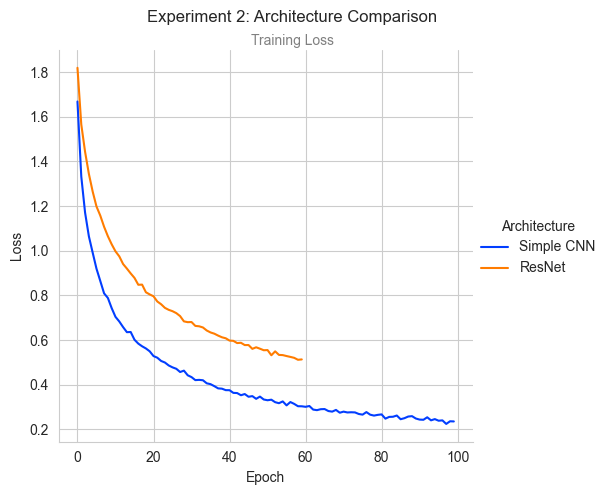

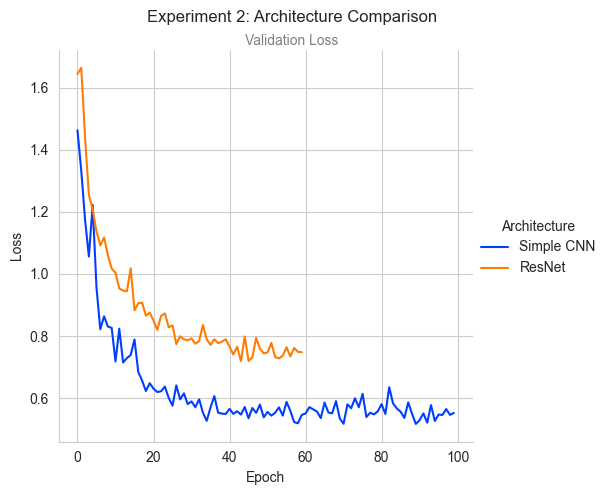

In [32]:
for identifier, df in plot_data_loss.items():
    df["Epoch"] = df.index
    df = pd.melt(df, id_vars=["Epoch"], var_name=independent_variable, value_name="Loss")
    # print(df)
    plots[identifier] = gen_plot(df, independent_variable, experiment_number, experiment_title, subtitle=identifier)
    plt.show()

Prepare DataFrame containing validation accuracy data and plot

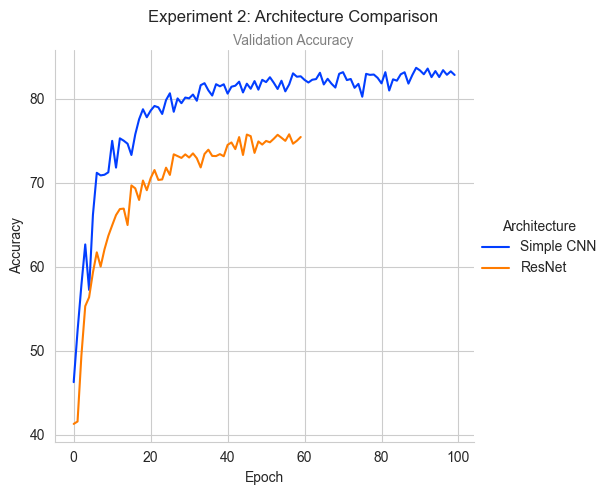

In [33]:
validation_accuracy["Epoch"] = validation_accuracy.index
validation_accuracy = pd.melt(validation_accuracy, id_vars=["Epoch"], var_name=independent_variable, value_name="Accuracy")
# print(df)
plots["Validation Accuracy"] = gen_plot(validation_accuracy, independent_variable, experiment_number, experiment_title, dependent_var="Accuracy", subtitle="Validation Accuracy")
plt.show()

Construct table of final test results

In [34]:
results.set_index(independent_variable, inplace=True)
display(results)

,Test Loss,Test Accuracy (%)
Architecture,,
Simple CNN,0.555492,83.95
ResNet,0.613830,79.05


Display epoch when convergence is found

In [35]:
print(f"Simple CNN converged at epoch: {len(simple_train_loss)}")
print(f"ResNet converged at epoch: {len(rn_train_loss)}")

Simple CNN converged at epoch: 100
ResNet converged at epoch: 60


Save all figures to disk

In [36]:
for identifier, g in plots.items():
    save_plot(g, experiment_number, experiment_title, suffix=f" - {identifier}")

save_table(results, experiment_number, experiment_title, suffix=f" - Results")

		 saved to ./results/exp_2/Architecture Comparison - Training Loss.png
		 saved to ./results/exp_2/Architecture Comparison - Validation Loss.png
		 saved to ./results/exp_2/Architecture Comparison - Validation Accuracy.png
		 saved to ./results/exp_2/Architecture Comparison - Results.xlsx


---

## Experiment C
*Optimizer Comparison* <br>
Examine how different optimizers effect the stability of training and speed of convergence

In [37]:
experiment_title = "Optimizer Comparison"
experiment_number = 3
independent_variable = "Optimizer"

**Independent Variable**

In [38]:
sgd_cnn = SimpleCNN(depth=3)
adam_cnn = SimpleCNN(depth=3)

### Experiment

Perform Training and Validation on models and capture statistical data <br>
*Notes* <br>
- Epsilon is set to prevent overfitting and provide more information about convergence speeds
- Each network is individually timed

In [39]:
epsilon = 0.0001

In [52]:
%%time
print("Starting training on SGD CNN...")
sgd_cnn, sgd_train_loss, sgd_valid_loss, sgd_valid_accuracy = train(sgd_cnn, training_data, validation_data, optimizer=torch.optim.SGD(sgd_cnn.parameters(), lr=0.001, weight_decay=0.0001), verbose=True, device=device, TOTAL_EPOCHES=200, THRESH=epsilon)
print("Training on SGD CNN complete!")

torch.cuda.synchronize()

Starting training on SGD CNN...
		Epoch 1/200
			training avg_loss=1.1410
			validation avg_loss=1.1423
			accuracy=58.45%
		Epoch 11/200
			training avg_loss=1.0960
			validation avg_loss=1.0814
			accuracy=61.13%
		Epoch 21/200
			training avg_loss=1.0574
			validation avg_loss=1.0711
			accuracy=60.75%
		Epoch 31/200
			training avg_loss=1.0304
			validation avg_loss=1.0201
			accuracy=63.21%
		Epoch 41/200
			training avg_loss=1.0015
			validation avg_loss=1.0168
			accuracy=62.89%
		Epoch 51/200
			training avg_loss=0.9690
			validation avg_loss=0.9992
			accuracy=64.15%
		Epoch 61/200
			training avg_loss=0.9466
			validation avg_loss=0.9555
			accuracy=65.29%
		Epoch 71/200
			training avg_loss=0.9256
			validation avg_loss=0.9630
			accuracy=65.92%
		Epoch 81/200
			training avg_loss=0.9090
			validation avg_loss=0.9654
			accuracy=65.15%
		Epoch 91/200
			training avg_loss=0.8808
			validation avg_loss=0.9155
			accuracy=67.41%
		Epoch 101/200
			training avg_loss=0.8644
			va

In [41]:
%%time
print("Starting training on ADAM CNN...")
adam_cnn, adam_train_loss, adam_valid_loss, adam_valid_accuracy = train(adam_cnn, training_data, validation_data, verbose=True, device=device, THRESH=epsilon)
print("Training on ADAM CNN complete!")

torch.cuda.synchronize()

Starting training on ADAM CNN...
		Epoch 1/100
			training avg_loss=1.6837
			validation avg_loss=1.5142
			accuracy=42.25%
		Epoch 11/100
			training avg_loss=0.7055
			validation avg_loss=0.8056
			accuracy=72.04%
		Epoch 21/100
			training avg_loss=0.5267
			validation avg_loss=0.7019
			accuracy=76.49%
		Epoch 31/100
			training avg_loss=0.4254
			validation avg_loss=0.5658
			accuracy=81.15%
		Epoch 41/100
			training avg_loss=0.3586
			validation avg_loss=0.5766
			accuracy=80.90%
		Epoch 51/100
			training avg_loss=0.3264
			validation avg_loss=0.5822
			accuracy=81.20%
		Epoch 61/100
			training avg_loss=0.2967
			validation avg_loss=0.5468
			accuracy=82.11%
		Epoch 71/100
			training avg_loss=0.2823
			validation avg_loss=0.5332
			accuracy=83.18%
		Epoch 81/100
			training avg_loss=0.2532
			validation avg_loss=0.5584
			accuracy=82.71%
Training on ADAM CNN complete!
CPU times: total: 9min 12s
Wall time: 50min 12s


Perform final testing on models and capture statistical data

In [53]:
sgd_test_loss, sgd_test_accuracy = [], []
adam_test_loss, adam_test_accuracy = [], []

In [54]:
%%time
print("Starting testing on SGD CNN...")
evaluate(sgd_cnn, testing_data, sgd_test_loss, sgd_test_accuracy)
print("Testing on SGD CNN complete!")

torch.cuda.synchronize()

Starting testing on SGD CNN...
Testing on SGD CNN complete!
CPU times: total: 16.9 s
Wall time: 30.9 s


In [55]:
%%time
print("Starting testing on ADAM CNN...")
evaluate(adam_cnn, testing_data, adam_test_loss, adam_test_accuracy)
print("Testing on ADAM CNN complete!")

torch.cuda.synchronize()

Starting testing on ADAM CNN...
Testing on ADAM CNN complete!
CPU times: total: 1min 5s
Wall time: 1min 19s


### Plotting

In [56]:
max_len = max(len(sgd_train_loss), len(adam_train_loss))

training_loss = pd.DataFrame({
    "SGD" : sgd_train_loss + [None] * (max_len - len(sgd_train_loss)),
    "ADAM" : adam_train_loss + [None] * (max_len - len(adam_train_loss)),
})

validation_loss = pd.DataFrame({
    "SGD" : sgd_valid_loss + [None] * (max_len - len(sgd_valid_loss)),
    "ADAM" : adam_valid_loss + [None] * (max_len - len(adam_valid_loss)),
})

validation_accuracy = pd.DataFrame({
    "SGD" : sgd_valid_accuracy + [None] * (max_len - len(sgd_valid_accuracy)),
    "ADAM" : adam_valid_accuracy + [None] * (max_len - len(adam_valid_accuracy)),
})

plot_data_loss = {
    "Training Loss" : training_loss,
    "Validation Loss" : validation_loss
}

results = pd.DataFrame({
    independent_variable: ["SGD", "ADAM"],
    "Test Loss": [sgd_test_loss[0], adam_test_loss[0]],
    "Test Accuracy (%)": [sgd_test_accuracy[0], adam_test_accuracy[0]]
})

Prepare DataFrame and plot results generated by the loss function

In [57]:
plots = dict()

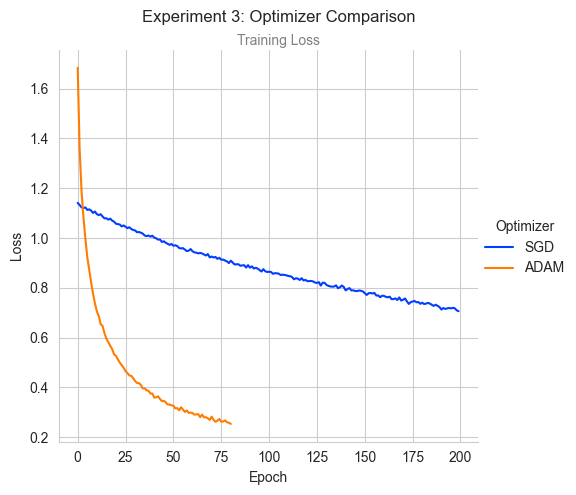

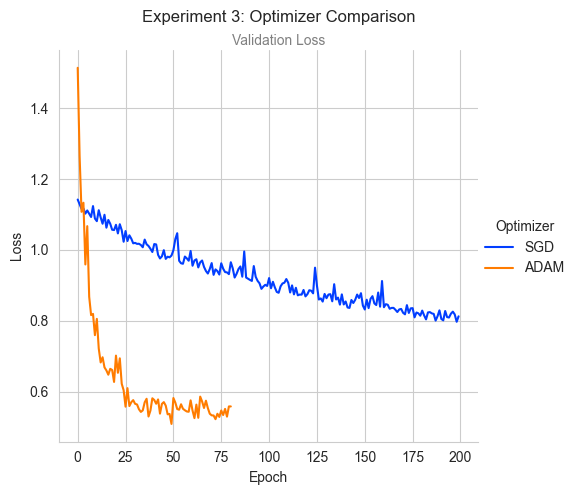

In [58]:
for identifier, df in plot_data_loss.items():
    df["Epoch"] = df.index
    df = pd.melt(df, id_vars=["Epoch"], var_name=independent_variable, value_name="Loss")
    # print(df)
    plots[identifier] = gen_plot(df, independent_variable, experiment_number, experiment_title, subtitle=identifier)
    plt.show()

Prepare DataFrame containing validation accuracy data and plot


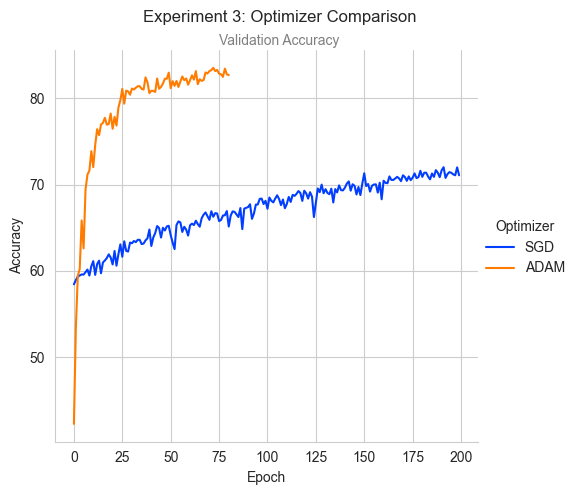

In [59]:
validation_accuracy["Epoch"] = validation_accuracy.index
validation_accuracy = pd.melt(validation_accuracy, id_vars=["Epoch"], var_name=independent_variable, value_name="Accuracy")
# print(df)
plots["Validation Accuracy"] = gen_plot(validation_accuracy, independent_variable, experiment_number, experiment_title, dependent_var="Accuracy", subtitle="Validation Accuracy")
plt.show()

Construct table of final test results


In [60]:
results.set_index(independent_variable, inplace=True)
display(results)

,Test Loss,Test Accuracy (%)
Optimizer,,
SGD,0.888703,68.75
ADAM,0.586008,83.03


Display epoch when convergence is found

In [61]:
print(f"SGD converged at epoch: {len(sgd_train_loss)}")
print(f"Adam converged at epoch: {len(adam_train_loss)}")

SGD converged at epoch: 200
Adam converged at epoch: 81


Save all figures to disk


In [62]:
for identifier, g in plots.items():
    save_plot(g, experiment_number, experiment_title, suffix=f" - {identifier}")

save_table(results, experiment_number, experiment_title, suffix=f" - Results")

		 saved to ./results/exp_3/Optimizer Comparison - Training Loss.png
		 saved to ./results/exp_3/Optimizer Comparison - Validation Loss.png
		 saved to ./results/exp_3/Optimizer Comparison - Validation Accuracy.png
		 saved to ./results/exp_3/Optimizer Comparison - Results.xlsx
